<a href="https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/showpieces/digits_retrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*Showpiece A · retraining notebook*

# Teach a network to read handwritten digits

> **In short**
>
> **How did the showpiece network learn to read digits?**
>
> It was shown 60,000 labelled digits. After each small batch it measured how wrong it was, then nudged its 52,266 weights to be a little less wrong. This notebook does that again, from scratch, in a few minutes.

## Where you'll end up

By the end you will have:

- a trained network that reads about 99 out of 100 test digits correctly
- this map of 3,000 training digits, grouped by what the network learned
- the three files the showpiece web page loads, ready to swap in

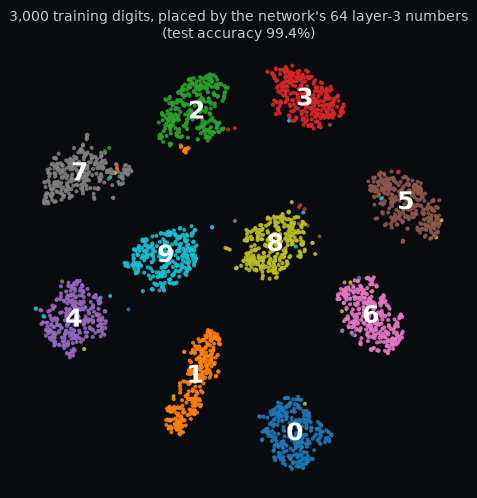

## How to use this notebook

- Each grey box is a **code cell**. Click it and press **Shift + Enter** to run it.
- Run the cells **in order**, top to bottom. Or use **Runtime → Run all**.
- The whole notebook takes about 5 minutes on Colab's free CPU. No GPU needed.

🐍 **Python notes** like this one explain new Python as it appears. You know how to program already;
these notes only cover what Python does differently.

## 1. The problem: 60,000 photos of handwriting

You want a program that reads handwritten digits.
Writing rules by hand fails fast: people write a 4 open, closed, slanted, tiny, huge.

Instead, you collect examples where the answer is known, and let a network learn from them.
The classic collection is called **MNIST**: 70,000 handwritten digits, each 28 × 28 pixels, each with a label.

In [1]:
# Load the digits. If MNIST can't be downloaded, fall back to a small set that ships with scikit-learn.
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

try:
    import torchvision
    train_set = torchvision.datasets.MNIST("data", train=True, download=True)
    test_set = torchvision.datasets.MNIST("data", train=False, download=True)
    x_train = train_set.data.float().div(255).unsqueeze(1)   # values from 0 to 1
    y_train = train_set.targets.clone()
    x_test = test_set.data.float().div(255).unsqueeze(1)
    y_test = test_set.targets.clone()
    SOURCE = "MNIST"
except Exception as e:
    print("MNIST download failed:", e)
    from sklearn.datasets import load_digits
    d = load_digits()
    x = torch.tensor(d.images, dtype=torch.float32).unsqueeze(1) / 16.0
    x = F.pad(F.interpolate(x, size=(20, 20), mode="bilinear"), (4, 4, 4, 4))  # 8x8 -> 28x28
    y = torch.tensor(d.target)
    cut = int(0.8 * len(x))
    x_train, y_train, x_test, y_test = x[:cut], y[:cut], x[cut:], y[cut:]
    SOURCE = "sklearn load_digits"

print(SOURCE, "| training images:", tuple(x_train.shape), "| test images:", tuple(x_test.shape))

MNIST | training images: (60000, 1, 28, 28) | test images: (10000, 1, 28, 28)


🐍 **Python notes**
- `import torch` loads a library. `import numpy as np` loads it under a shorter name.
- `try:` / `except Exception as e:` runs the first block; if it fails, it runs the second instead.
- The shape `(60000, 1, 28, 28)` means: 60,000 images, 1 colour channel (grey), 28 rows, 28 columns.
  A multi-dimensional array like this is called a **tensor**.

### 🤔 Predict first

One image is 28 × 28 pixels. **How many numbers does the network receive for one image?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

28 × 28 = **784** numbers. Each one is a pixel: 0 is empty paper, 1 is full ink.

</details>

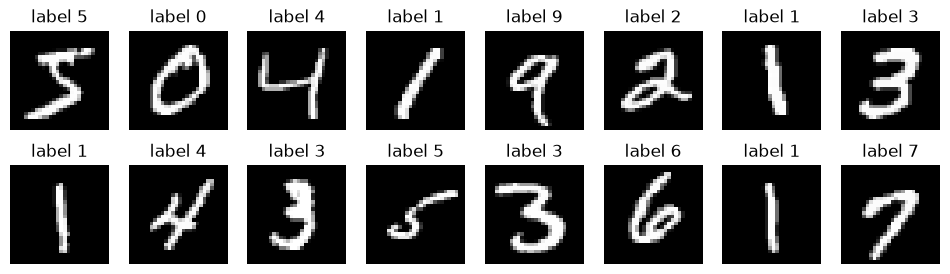

[[0.  0.  0.  0.1 0.9 1.  1.  1.  1.  1.  0.8 0.7 1.  0.9 0.  0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.3 0.6 0.4 1.  1.  0.8 0.  0.  0.2 0.6 0.  0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.1 0.  0.6 1.  0.4 0.  0.  0.  0.  0.  0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.5 1.  0.7 0.  0.  0.  0.  0.  0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.7 1.  0.3 0.  0.  0.  0.  0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.9 0.9 0.6 0.4 0.  0.  0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.3 0.9 1.  1.  0.5 0.1 0.  0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.7 1.  1.  0.6 0.1 0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.4 1.  1.  0.7 0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  1.  0.3 0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.5 0.7 1.  1.  0.8 0.  0.
  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0.  0.  0.2 0.6 0.9 1.  1.  1.  1.  0.7 0.  0.
  0

In [2]:
# Look at the first 16 training digits with their labels
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i, 0], cmap="gray")
    ax.set_title(f"label {y_train[i].item()}")
    ax.axis("off")
plt.show()

# One digit, as the numbers the network actually sees (rows 8 to 19, rounded to 1 decimal)
print(np.round(x_train[0, 0, 8:20, 4:24].numpy(), 1))

🐍 `for i, ax in enumerate(axes.flat):` loops over the 16 small plots and also counts them (`i` = 0, 1, 2, …).
`f"label {y}"` is an **f-string**: the part in `{}` is replaced by its value.

**What you see:** the image is a grid of numbers. Ink is near 1, paper is 0. That grid is the whole input.

## 2. Build the network

The network has four layers. Each one takes a set of numbers and produces a new set:

| Layer | What it does, literally | Output size |
|---|---|---|
| 1 | Slides 8 small 5 × 5 patterns (**filters**) over the image. Each filter makes one grid that is bright where it matches. Then halves each grid by keeping the biggest number in every 2 × 2 block. | 8 × 14 × 14 |
| 2 | Slides 16 filters over those 8 grids, then halves again. | 16 × 7 × 7 = 784 |
| 3 | Every one of the 784 numbers is multiplied by a weight and added up, 64 different ways. | 64 |
| 4 | Same again, 10 ways: one **score** per digit. | 10 |

After layers 1–3, any negative number is set to 0. That step is called **ReLU**. Without it, the four layers would collapse into one big multiply.

In [3]:
class DigitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 5, padding=2)    # 8 filters, 5x5
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)   # 16 filters, 3x3, each looks at all 8 grids
        self.fc1 = nn.Linear(16 * 7 * 7, 64)          # 784 numbers -> 64
        self.fc2 = nn.Linear(64, 10)                  # 64 -> 10 scores

    def forward(self, x, return_all=False):
        c1 = F.relu(self.conv1(x))
        p1 = F.max_pool2d(c1, 2)          # halve: keep the biggest of each 2x2 block
        c2 = F.relu(self.conv2(p1))
        p2 = F.max_pool2d(c2, 2)
        hidden = F.relu(self.fc1(p2.flatten(1)))
        scores = self.fc2(hidden)
        if return_all:
            return dict(c1=c1, p1=p1, c2=c2, p2=p2, hidden=hidden, logits=scores)
        return scores

model = DigitNet()
for name, p in model.named_parameters():
    print(f"{name:14s} {str(tuple(p.shape)):16s} {p.numel():>6,d} weights")
print("total:", sum(p.numel() for p in model.parameters()))

conv1.weight   (8, 1, 5, 5)        200 weights
conv1.bias     (8,)                  8 weights
conv2.weight   (16, 8, 3, 3)     1,152 weights
conv2.bias     (16,)                16 weights
fc1.weight     (64, 784)        50,176 weights
fc1.bias       (64,)                64 weights
fc2.weight     (10, 64)            640 weights
fc2.bias       (10,)                10 weights
total: 52266


🐍 **Python notes**
- `class DigitNet(nn.Module):` defines a class that builds on PyTorch's `nn.Module`.
- `__init__` runs when you create one (`model = DigitNet()`). `self` is the object itself, like `this` in Java or C++.
- `forward` is what happens when you call `model(x)`.

### 🤔 Predict first

There are four layers. **Which one do you think holds most of the 52,266 weights?**

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Layer 3 (`fc1`): 784 × 64 + 64 = **50,240 weights**, about 96% of the total.

The filter layers are tiny: layer 1 has 8 × 25 + 8 = 208. A filter reuses the same 25 weights at every position in the image.
That reuse is why filters are cheap.

</details>

## 3. Make the training digits messier on purpose

**Problem:** a digit drawn with a mouse is not like a scanned pen digit.
It can be thicker, slanted, shifted, or bigger.
A network trained only on neat MNIST digits can stumble on yours.

**Fix:** every time a batch is used, bend each digit a little at random: rotate, shift, zoom, slant, thicken.
The network never sees the exact same image twice. This is called **data augmentation**.

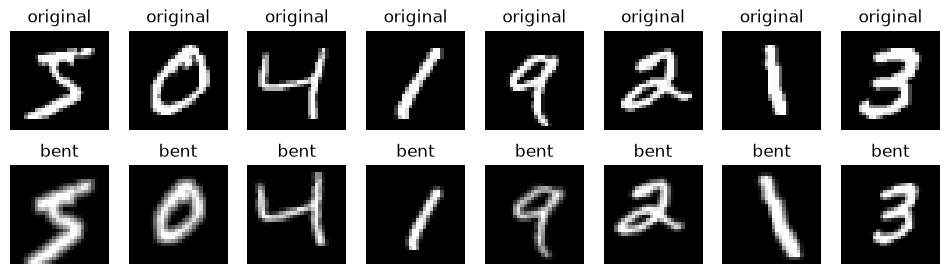

In [4]:
import math

def augment(x):
    n = x.shape[0]
    angle = (torch.rand(n) * 2 - 1) * math.radians(14)        # rotate up to 14 degrees
    zoom = 1 / (0.78 + torch.rand(n) * 0.40)                   # 0.78x to 1.18x
    slant = (torch.rand(n) * 2 - 1) * 0.25
    shift_x = (torch.rand(n) * 2 - 1) * 0.16
    shift_y = (torch.rand(n) * 2 - 1) * 0.16
    cos, sin = torch.cos(angle), torch.sin(angle)
    theta = torch.zeros(n, 2, 3)                               # one 2x3 matrix per image
    theta[:, 0, 0] = cos * zoom
    theta[:, 0, 1] = (-sin + slant) * zoom
    theta[:, 1, 0] = sin * zoom
    theta[:, 1, 1] = cos * zoom
    theta[:, 0, 2] = shift_x
    theta[:, 1, 2] = shift_y
    grid = F.affine_grid(theta, list(x.shape), align_corners=False)
    out = F.grid_sample(x, grid, align_corners=False)
    # thicker strokes for 30% of images, thinner for 15%
    r = torch.rand(n)
    thick, thin = r < 0.30, (r >= 0.30) & (r < 0.45)
    out[thick] = F.max_pool2d(out[thick], 3, stride=1, padding=1) * 0.5 + out[thick] * 0.5
    out[thin] = out[thin] * 0.6 - F.max_pool2d(-out[thin], 3, stride=1, padding=1) * 0.4
    return out.clamp(0, 1)

sample = augment(x_train[:8].repeat(2, 1, 1, 1))
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for i, ax in enumerate(axes.flat):
    ax.imshow((x_train[i % 8, 0] if i < 8 else sample[i, 0]), cmap="gray")
    ax.set_title("original" if i < 8 else "bent")
    ax.axis("off")
plt.show()

**What you see:** top row, the originals. Bottom row, the same digits bent at random.

The bending is a 2 × 2 matrix per image (rotate, zoom, slant) plus a shift.
That is the same kind of matrix your linear algebra course uses to move points and transform the grid.

🐍 `x[:8]` means "the first 8 items". `out[thick]` picks only the images where `thick` is `True`.

## 4. Train: guess, measure the error, nudge the weights

One training step:

1. **Guess.** Run a batch of 128 digits through the network. Get 10 scores per digit.
2. **Measure the error.** Turn scores into probabilities. Look at the probability given to the *correct* digit.
   The error is $-\log(p_{\text{correct}})$: 0 when the network is 100% sure and right, large when it gives the right answer a tiny probability.
3. **Nudge.** For each of the 52,266 weights, work out which direction would lower the error, and move it a small step that way.

Repeat for every batch. One full pass over all 60,000 digits is called an **epoch**.

### 🤔 Predict first

After the first epoch, what fraction of the test digits do you think the network gets right? A: about 10% (random guessing). B: about 50%. C: over 90%.

<details><summary><b>Show me the answer</b> (or skip it, and run the next cell)</summary>

Run the next cell and look at the first line it prints. (Usually **C**: well over 90% after one pass.)

</details>

In [5]:
import time

EPOCHS = 15            # try 3 for a quick run
BATCH = 128

@torch.no_grad()
def accuracy(model, x, y):
    model.eval()
    preds = torch.cat([model(x[i:i + 1000]).argmax(1) for i in range(0, len(x), 1000)])
    return (preds == y).float().mean().item()

model = DigitNet()
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
steps = EPOCHS * math.ceil(len(x_train) / BATCH)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, total_steps=steps)
losses, test_accs = [], []
start = time.time()

for epoch in range(EPOCHS):
    model.train()
    order = torch.randperm(len(x_train))            # new random order each epoch
    for i in range(0, len(x_train), BATCH):
        idx = order[i:i + BATCH]
        scores = model(augment(x_train[idx]))        # 1. guess
        loss = F.cross_entropy(scores, y_train[idx])  # 2. measure the error
        opt.zero_grad()
        loss.backward()                               # 3a. which way should each weight move?
        opt.step()                                    # 3b. move it a small step
        sched.step()
        losses.append(loss.item())
    test_accs.append(accuracy(model, x_test, y_test))
    print(f"epoch {epoch + 1:2d}: test accuracy {test_accs[-1] * 100:.2f}%   ({time.time() - start:.0f}s so far)")

epoch  1: test accuracy 86.91%   (4s so far)


epoch  2: test accuracy 96.27%   (8s so far)


epoch  3: test accuracy 97.35%   (12s so far)


epoch  4: test accuracy 98.34%   (16s so far)


epoch  5: test accuracy 98.02%   (20s so far)


...

epoch 11: test accuracy 99.11%   (46s so far)


epoch 12: test accuracy 99.06%   (49s so far)


epoch 13: test accuracy 99.22%   (53s so far)


epoch 14: test accuracy 99.25%   (57s so far)


epoch 15: test accuracy 99.23%   (60s so far)


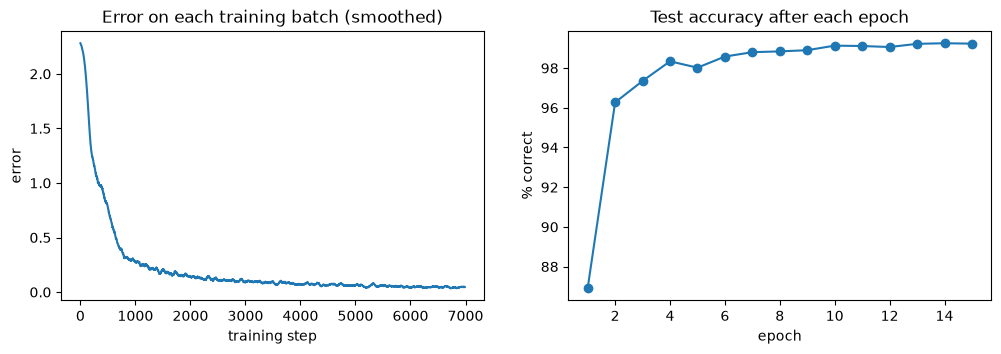

In [6]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
a.plot(np.convolve(losses, np.ones(50) / 50, mode="valid"))
a.set_title("Error on each training batch (smoothed)"); a.set_xlabel("training step"); a.set_ylabel("error")
b.plot(range(1, len(test_accs) + 1), [t * 100 for t in test_accs], marker="o")
b.set_title("Test accuracy after each epoch"); b.set_xlabel("epoch"); b.set_ylabel("% correct")
plt.show()

**What you see:** the error drops fast, then slowly. Test accuracy climbs above 99%.

**What it's called:** measuring the error this way is *cross-entropy loss*.
Working out which way each weight should move is *backpropagation* (`loss.backward()`).
Moving every weight a small step downhill is *gradient descent* (`opt.step()`).
The [How models learn notebook](https://colab.research.google.com/github/novakai-one/claude-ai-demo/blob/main/notebooks/fields/01_how_models_learn.ipynb) builds `backward()` from scratch so you can see inside it.

🐍 `@torch.no_grad()` above a function is a *decorator*: it wraps the function so PyTorch doesn't track gradients inside it (faster, less memory).

## 5. What does it still get wrong?

Test digits were never used for training. They show how the network does on writing it has never seen.

77 wrong out of 10000


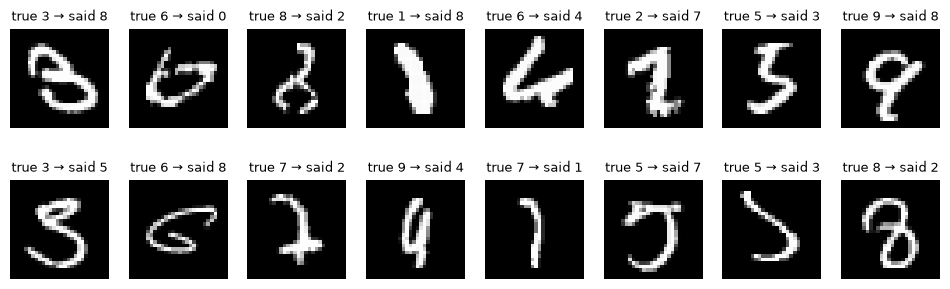

In [7]:
model.eval()
with torch.no_grad():
    test_scores = torch.cat([model(x_test[i:i + 1000]) for i in range(0, len(x_test), 1000)])
test_pred = test_scores.argmax(1)
wrong = (test_pred != y_test).nonzero().flatten()
print(f"{len(wrong)} wrong out of {len(y_test)}")

fig, axes = plt.subplots(2, 8, figsize=(12, 3.6))
for ax, i in zip(axes.flat, wrong[:16]):
    ax.imshow(x_test[i, 0], cmap="gray")
    ax.set_title(f"true {y_test[i].item()} → said {test_pred[i].item()}", fontsize=9)
    ax.axis("off")
plt.show()

**What you see:** many mistakes are digits a person might misread too.
A few are plain errors. Look for pairs that come up again and again (4 ↔ 9, 3 ↔ 5, 2 ↔ 7).

## 6. Make the map

Layer 3 turns every digit into 64 numbers. You can't plot 64 dimensions.
Two ways to squash 64 numbers down to 2:

- **PCA** (linear algebra): find the two directions in which the 64-number points spread out most, and measure each point along them. One fixed matrix multiply.
- **t-SNE**: move points around in 2-D until close neighbours in 64-D are close neighbours on the page. Not a fixed formula, but the clusters separate much better.

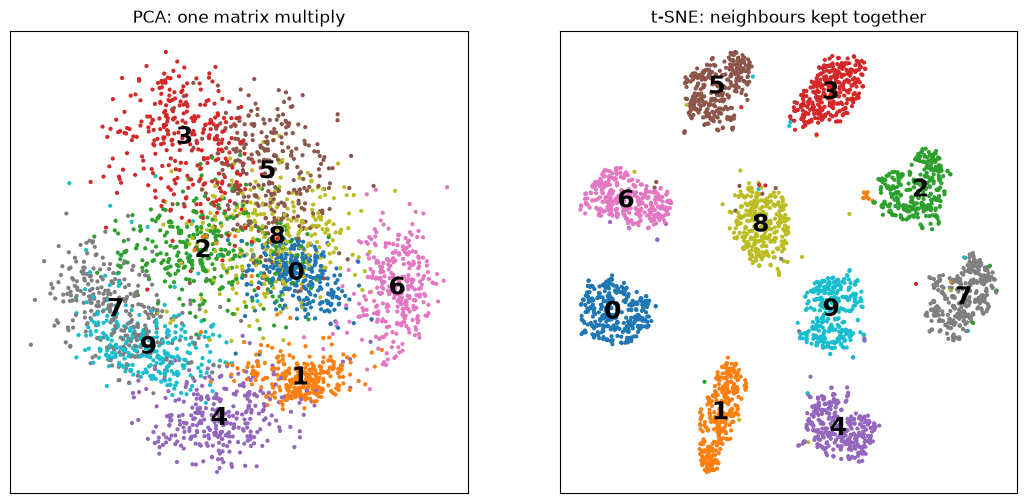

In [8]:
# 300 training digits of each kind
g = torch.Generator().manual_seed(7)
pick = torch.cat([(y_train == d).nonzero().flatten()[torch.randperm(int((y_train == d).sum()), generator=g)[:300]]
                  for d in range(10)])
pick = pick[torch.randperm(len(pick), generator=g)]
with torch.no_grad():
    out = model(x_train[pick], return_all=True)
H = out["hidden"].numpy()             # 3000 x 64
labels = y_train[pick].numpy()

# PCA by hand: centre the points, then the top two right singular vectors are the two directions
mean = H.mean(0)
U, S, Vt = np.linalg.svd(H - mean, full_matrices=False)
directions = Vt[:2]                    # 2 x 64
pca_xy = (H - mean) @ directions.T    # 3000 x 2: one matrix multiply

from sklearn.manifold import TSNE
tsne_xy = TSNE(n_components=2, perplexity=35, init="pca", random_state=0).fit_transform(H)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, xy, title in [(axes[0], pca_xy, "PCA: one matrix multiply"), (axes[1], tsne_xy, "t-SNE: neighbours kept together")]:
    ax.scatter(xy[:, 0], xy[:, 1], c=labels, cmap="tab10", s=4)
    for d in range(10):
        c = np.median(xy[labels == d], axis=0)
        ax.text(c[0], c[1], str(d), fontsize=18, weight="bold", ha="center", va="center")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.show()

**What you see:** in the PCA map, clusters overlap. One flat view can't separate ten groups.
In the t-SNE map, each digit gets its own island.

**What it's called:** the two PCA directions are the top two *eigenvectors* of the data's covariance matrix.
`np.linalg.svd` finds them for you. (SVD is a close cousin of eigen-decomposition; your linear algebra course may cover it.)

## 7. Export the files the web page loads

The showpiece page runs the network in your browser with plain TypeScript.
It needs three files. This cell writes them in exactly the format the page expects.

In [9]:
import base64, json, os
from PIL import Image

os.makedirs("export", exist_ok=True)
b64 = lambda t: base64.b64encode(t.detach().float().contiguous().numpy().astype("<f4").tobytes()).decode()

with torch.no_grad():
    acts = model(x_test[:2000], return_all=True)
act_scale = {k: float(torch.quantile(v.flatten()[v.flatten() > 0][:2_000_000], 0.995))
             for k, v in acts.items() if k in ("c1", "c2", "hidden")}
conf = np.zeros((10, 10), int)
for t, p in zip(y_test.tolist(), test_pred.tolist()):
    conf[t, p] += 1
pairs = sorted((((a, b), int(conf[a, b] + conf[b, a])) for a in range(10) for b in range(a + 1, 10)), key=lambda p: -p[1])
acc = accuracy(model, x_test, y_test)

layers = {n: {"shape": list(p.shape), "data": b64(p)} for n, p in model.named_parameters()}
json.dump({"source": SOURCE, "test_accuracy": round(acc, 4), "test_count": len(x_test),
           "confused_pairs": [{"a": a, "b": b, "count": c} for (a, b), c in pairs[:6]],
           "act_scale": act_scale, "layers": layers}, open("export/model.json", "w"))

def norm(xy):
    lo, hi = xy.min(0), xy.max(0)
    span, mid = (hi - lo).max(), (hi + lo) / 2
    return (xy - mid) / span * 0.92 + 0.5, {"mid": mid.tolist(), "span": float(span)}

pca_n, pca_norm = norm(pca_xy)
tsne_n, _ = norm(tsne_xy)
hmax = H.max(0) + 1e-6
hq = np.clip(np.round(H / hmax * 255), 0, 255).astype(np.uint8)
json.dump({
    "count": len(pick), "labels": "".join(map(str, labels)),
    "preds": "".join(map(str, out["logits"].argmax(1).numpy())),
    "pca": {"xy": np.round(pca_n, 4).flatten().tolist(), "mean": mean.round(5).tolist(),
            "comps": directions.round(6).tolist(), **pca_norm},
    "tsne": {"xy": np.round(tsne_n, 4).flatten().tolist()},
    "hidden": {"max": hmax.round(5).tolist(), "data": base64.b64encode(hq.tobytes()).decode()},
    "sprite": {"cols": 60, "tile": 28},
}, open("export/map.json", "w"))

sheet = np.zeros((50 * 28, 60 * 28), np.uint8)
imgs = (x_train[pick, 0].numpy() * 255).round().astype(np.uint8)
for i, im in enumerate(imgs):
    r, c = divmod(i, 60)
    sheet[r * 28:(r + 1) * 28, c * 28:(c + 1) * 28] = im
Image.fromarray(sheet).save("export/sprites.png", optimize=True)
print(os.listdir("export"))

['sprites.png', 'model.json', 'map.json']


**To use your own network on the site:** download the three files (left sidebar → folder icon → `export`),
then copy them into `site/public/models/digits/` in the repo, replacing the old ones. Reload the page.

## Practice

Try these before opening the solutions.

### Exercise 1

Layer 2 has 16 filters. Each filter is 3 × 3 and looks at all 8 grids from layer 1. Each filter also has one bias. **How many weights does layer 2 have?** Work it out by hand, then check with code.

In [10]:
# your check here

In [ ]:
#@title Solution to exercise 1 (double-click to show)
print(16 * (8 * 3 * 3) + 16)   # 1,168
print(model.conv2.weight.numel() + model.conv2.bias.numel())

### Exercise 2

Find the 8 test digits the network is **least sure** about (lowest top probability), and show them with their top two guesses.

In [12]:
# your code here

In [ ]:
#@title Solution to exercise 2 (double-click to show)
probs = F.softmax(test_scores, dim=1)
top2 = probs.topk(2, dim=1)
unsure = top2.values[:, 0].argsort()[:8]
fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, i in zip(axes, unsure):
    (p1, p2), (d1, d2) = top2.values[i].tolist(), top2.indices[i].tolist()
    ax.imshow(x_test[i, 0], cmap="gray"); ax.axis("off")
    ax.set_title(f"{d1}:{p1:.0%} {d2}:{p2:.0%}", fontsize=9)
plt.show()

## Recognition cues

- When you see **images, or any grid of numbers** in a problem, think **small filters that slide across the grid (a CNN)**.
- When you see **"the real inputs will look different from the training data"** in a problem, think **augment the training data**.
- When you see **"which examples does the model treat as alike?"** in a problem, think **take a hidden layer's numbers and map them to 2-D (PCA or t-SNE)**.

## Try changing this

1. **Turn off augmentation.** In the training loop, replace `augment(x_train[idx])` with `x_train[idx]`. Test accuracy barely changes. Then export and try the site: does it still read *your* drawings as well?
2. **Shrink layer 3** from 64 to 8 numbers (change `64` in two places). What happens to accuracy, and to the map?
3. **Train for 1 epoch** (`EPOCHS = 1`). How close does it get? How much do the last 14 epochs add?

## Open research questions

People are working on these right now:

- Why do huge networks generalise instead of memorising?
- Can models learn from far less data?
- Can we read a model's "thoughts" reliably?

Any of them could become a thesis topic.

## Spark Log

Before you close this notebook, write three things about **How models learn (and this showpiece)** in your Spark Log (the Spark Log page on the site):

1. **What surprised me?**
2. **What would I want to know next?**
3. **Excitement, 1 to 10.** How much would you enjoy a year of this?

Write it now, while it's fresh. You will compare fields later.